In [1]:
from collections import deque
import json
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from galaxy_dataset import get_dataloader
from VQ_VAE_utils import construct_vae, optimizer, train

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\alexa\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\alexa\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\alexa\AppData\Local\Programs\Python\Python310\lib\site-packages\lpips\weights\v0.1\alex.pth


### Hyperparams

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("models/vae_v1_hyperparams.json", "r") as f:
    hyperparams = json.load(f)

embedding_dim = hyperparams["embedding_dim"]
num_embeddings = hyperparams["num_embeddings"]
commitment = hyperparams["commitment"]
epochs = hyperparams["epochs"]
batch_size = hyperparams["batch_size"]

### Read and Preprocess Dataset

In [3]:
image_folder = 'training_images'
image_size = (128, 128)

train_loader = get_dataloader(image_folder, image_size, batch_size, n=200000)

### Create VAE & Optimizer

In [4]:
vae = construct_vae(device, embedding_dim, num_embeddings, commitment)

#### Gathering Test Samples

In [42]:
seen_images = deque(maxlen=10)

for batch in train_loader:
    for img in batch:
        seen_images.append(img)
    break

seen_images = torch.stack(list(seen_images))

test_loader = get_dataloader(image_folder, image_size, batch_size, n=200100)

unseen_images = deque(maxlen=10)

i = 1
for batch in test_loader:
    if i < len(test_loader):
        i += 1
        continue
    for img in batch:
        unseen_images.append(img)

unseen_images = torch.stack(list(unseen_images))

### Train Model

In [ ]:
training_state_path = 'state.json'

try:
    with open(training_state_path, 'r') as file:
        training_state_data = json.load(file)
    vae.load_state_dict(torch.load(f"vae_checkpoint_{training_state_data['last_epoch']}.pth", weights_only=True))
except:
    training_state_data = {
        'last_epoch': 0,
        'lambda': [],
        'total_loss': [],
        'recon_loss': [],
        'codebook_loss': [],
        'codebook_usage': [],
    }

for epoch in range(training_state_data['last_epoch'] + 1, epochs + 1):
    lmd = 0.1 if epoch <= 5 else 0.1 * (epoch / epochs)
    learning_rate = 3e-4 if epoch <= 5 else 3e-4 if epoch < 50 else 1e-4
    opt = optimizer(vae, learning_rate)
    avg_total_loss, avg_rec_loss, avg_vq_loss, used_indices = train(vae, device, train_loader, opt, lmd_lpips=lmd)
    
    print(f"\nEpoch [{epoch}/{epochs}]")
    print(f"Total Loss: {avg_total_loss:.4f}")
    print(f"Reconstruction Loss: {avg_rec_loss:.4f}")
    print(f"Codebook Loss: {avg_vq_loss:.4f}")
    print(f"Used {100 * used_indices / vae.vq.num_embeddings:.2f}% codebook entries\n")
    
    recon, *_ = vae(seen_images.to(device))
    comparison = torch.cat([seen_images, recon.cpu()])
    vutils.save_image(comparison, f'recon_epoch_{epoch}.png', nrow=8, normalize=True)
    
    training_state_data['last_epoch'] = epoch
    training_state_data['lambda'] = lmd
    training_state_data['total_loss'].append(avg_total_loss)
    training_state_data['recon_loss'].append(avg_rec_loss)
    training_state_data['codebook_loss'].append(avg_vq_loss)
    training_state_data['codebook_usage'].append(used_indices / vae.vq.num_embeddings)
    
    torch.save(vae.state_dict(), f"vae_checkpoint_{epoch}.pth")
    with open(training_state_path, 'w') as state_file:
        json.dump(training_state_data, state_file)

100%|██████████| 3125/3125 [11:39<00:00,  4.47it/s]



Epoch [77/100]
Total Loss: 0.0134
Reconstruction Loss: 0.0103
Codebook Loss: 0.0004
Used 77.93% codebook entries



100%|██████████| 3125/3125 [11:40<00:00,  4.46it/s]



Epoch [78/100]
Total Loss: 0.0134
Reconstruction Loss: 0.0104
Codebook Loss: 0.0004
Used 78.03% codebook entries



100%|██████████| 3125/3125 [11:47<00:00,  4.42it/s]


...


Epoch [98/100]
Total Loss: 0.0137
Reconstruction Loss: 0.0105
Codebook Loss: 0.0005
Used 82.23% codebook entries



100%|██████████| 3125/3125 [11:50<00:00,  4.40it/s]



Epoch [99/100]
Total Loss: 0.0137
Reconstruction Loss: 0.0105
Codebook Loss: 0.0005
Used 82.42% codebook entries



100%|██████████| 3125/3125 [11:47<00:00,  4.42it/s]



Epoch [100/100]
Total Loss: 0.0137
Reconstruction Loss: 0.0105
Codebook Loss: 0.0005
Used 82.42% codebook entries



In [16]:
total_loss = training_state_data['total_loss']
recon_loss = training_state_data['recon_loss']
codebook_loss = training_state_data['codebook_loss']
codebook_usage = training_state_data['codebook_usage']

Text(0.5, 0, 'Epoch')

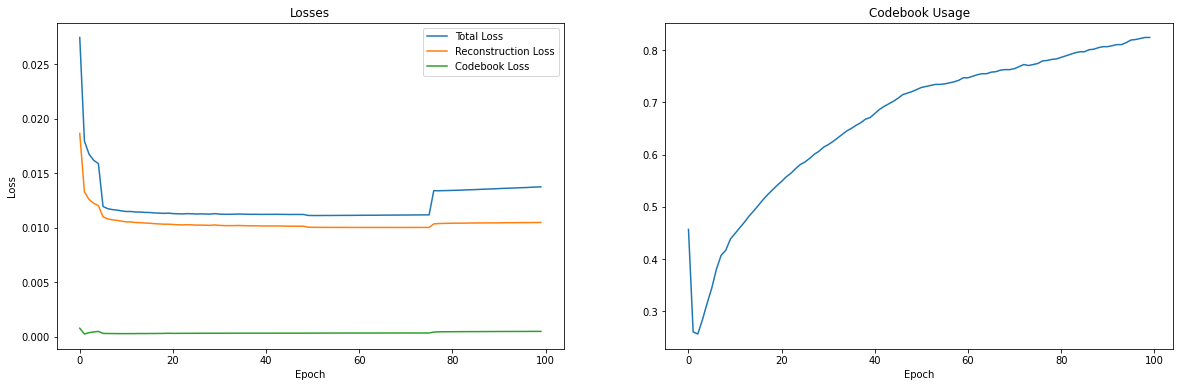

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6), facecolor='white')


ax[0].plot(total_loss, label='Total Loss')
ax[0].plot(recon_loss, label='Reconstruction Loss')
ax[0].plot(codebook_loss, label='Codebook Loss')
ax[0].set_title('Losses')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(codebook_usage, label='Codebook Usage')
ax[1].set_title('Codebook Usage')
ax[1].set_xlabel('Epoch')